# 02 · Modelos: brecha, tipos de zona y dónde sumar cajeros

**TPO Ciencia de Datos · ¿Dónde faltan cajeros Link en CABA?**

Fases de CRISP-DM: **preparación**, **modelado** y **evaluación**. Usamos tres técnicas y cada una responde una pregunta
distinta del negocio:

| Técnica | Tipo | Pregunta |
|---|---|---|
| Regresión de conteos | supervisada | ¿Cuántas terminales tienen las zonas con esta demanda? → **brecha** |
| K-Means | no supervisada | ¿Qué tipos de zona hay y dónde se concentra la brecha? |
| Cobertura máxima (MCLP) | prescriptiva | Si se suman N cajeros, ¿dónde ubicarlos para llegar a más gente? |

Al final validamos contra datos que el modelo no vio: los cajeros que aparecieron en OpenStreetMap después de 2017.

In [1]:
import json, sys, time
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import estilo as e, features as f, modelos as m, red as rp

e.mpl_estilo()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
FIG = RAIZ / "docs/figuras"; FIG.mkdir(parents=True, exist_ok=True)

tabla = f.construir()  # variables por hexágono, a partir de data/base
cajeros = f.cargar_cajeros()
HAY_RED = rp.hay_red()
if HAY_RED:  # distancias caminando por la red peatonal de OpenStreetMap
    red = rp.RedPeatonal.desde_archivos()
    tabla = rp.agregar_distancias_red(tabla, cajeros, red)
SUF = "_red" if HAY_RED else ""
print("Distancias:", "caminando por las calles" if HAY_RED else "en línea recta")
barrios = f.cargar_barrios()
print(f"{e.num_es(len(tabla))} hexágonos · {e.num_es(tabla['poblacion'].sum())} residentes · {e.num_es(tabla['term_total'].sum())} terminales")

Distancias: caminando por las calles
2.793 hexágonos · 3.088.735 residentes · 2.673 terminales


## 1. Planteo del modelo

- **Unidad:** hexágono H3 (resolución 9). Variables y objetivo se miden en el **área de influencia** (hexágono + 6 vecinos, ≈400 m).
- **Objetivo:** terminales de cajero (de cualquier red) en el área de influencia. Es un **conteo**, con muchos ceros y cola larga,
  por eso usamos modelos con pérdida de Poisson y medimos con la **devianza de Poisson** (D²: proporción explicada, el R² de los conteos).
- **Variables:** solo de **demanda** (residentes, perfil socioeconómico, comercio, pasajeros, distancia al centro y al subte).
  Dejamos afuera las sucursales bancarias: son oferta, y el modelo terminaría explicando cajeros con cajeros.
- **Filas:** hexágonos con algo de demanda (se excluyen río, reservas y playones vacíos).

In [2]:
X, y, grupos, mascara = m.preparar(tabla)
print(f"{e.num_es(len(X))} hexágonos para modelar · {X.shape[1]} variables")
pd.DataFrame({"variable": X.columns, "descripción": [m.NOMBRES.get(c, c) for c in X.columns],
              "mediana": X.median().values, "máximo": X.max().values})

2.740 hexágonos para modelar · 14 variables


,variable,descripción,mediana,máximo
0,poblacion_k1,Residentes en el área,"6,844.790","29,551.160"
1,actividad_osm_k1,Comercios y servicios (OSM),41.000,835.000
2,pax_subte_habil_k1,Pasajeros de subte por día hábil,0.000,"54,272.000"
3,estaciones_tren_k1,Estaciones de tren,0.000,3.000
4,dist_centro_km,Distancia a Plaza de Mayo (km),8.807,15.316
5,dist_subte_m,Distancia al subte (m),"1,399.702","6,653.628"
6,pct_nbi_k1,% hogares con NBI,0.035,0.330
7,pct_sin_internet_k1,% hogares sin internet,0.099,0.583
8,pct_65_k1,% de 65 años o más,0.175,0.284
9,pct_univ_k1,% con nivel universitario,0.173,0.415


## 2. Comparación de modelos con validación cruzada espacial

Los hexágonos vecinos se parecen (autocorrelación espacial) y además comparten área de influencia. Si mezclamos al azar
entrenamiento y prueba, el modelo "ve" la respuesta en los vecinos y el error parece menor de lo que es. Por eso evaluamos
dejando afuera **una comuna entera por vez** (GroupKFold por comuna, 5 particiones) y lo comparamos con la validación aleatoria.

Modelos, de menor a mayor complejidad (los de clase: árbol de decisión, Random Forest y boosting, más dos referencias
estadísticas y un ensamble definido de antemano):

In [3]:
t0 = time.time()
metricas, oof = m.comparar(X, y, grupos)
print(f"Validación terminada en {time.time() - t0:.0f} s")
tabla_metricas = metricas.pivot_table(index="modelo", columns="validación", values=["D² Poisson", "MAE", "R²"])
orden = metricas[metricas["validación"].str.startswith("espacial")].sort_values("D² Poisson", ascending=False)["modelo"]
tabla_metricas.loc[orden]

Validación terminada en 39 s


D² Poisson                             MAE  \
validación                         aleatoria espacial (por comuna) aleatoria   
modelo                                                                         
Regresión de Poisson (GLM)             0.746                 0.623     3.724   
Ensamble (Poisson GLM + Boosting)      0.815                 0.615     3.088   
Random Forest                          0.820                 0.564     3.112   
Gradient Boosting (Poisson)            0.836                 0.521     2.801   
Árbol de decisión (CART)               0.680                 0.495     4.258   
Línea de base (promedio)              -0.003                -0.110     7.746   
Poisson solo con población             0.097                -0.138     6.792   

                                                               R²  \
validación                        espacial (por comuna) aleatoria   
modelo                                                              
Regresión de Poisson (GLM)                        4.471     0.739   
Ensamble (Poisson GLM + Boosting)                 4.176     0.817   
Random Forest                                     4.335     0.770   
Gradient Boosting (Poisson)                       4.187     0.833   
Árbol de decisión (CART)                          4.812     0.583   
Línea de base (promedio)                          8.012    -0.001   
Poisson solo con población                        7.114     0.053   

                                                         
validación                        espacial (por comuna)  
modelo                                                   
Regresión de Poisson (GLM)                        0.378  
Ensamble (Poisson GLM + Boosting)                 0.363  
Random Forest                                     0.305  
Gradient Boosting (Poisson)                       0.297  
Árbol de decisión (CART)                          0.277  
Línea de base (promedio)                         -0.042  
Poisson solo con población                        0.012

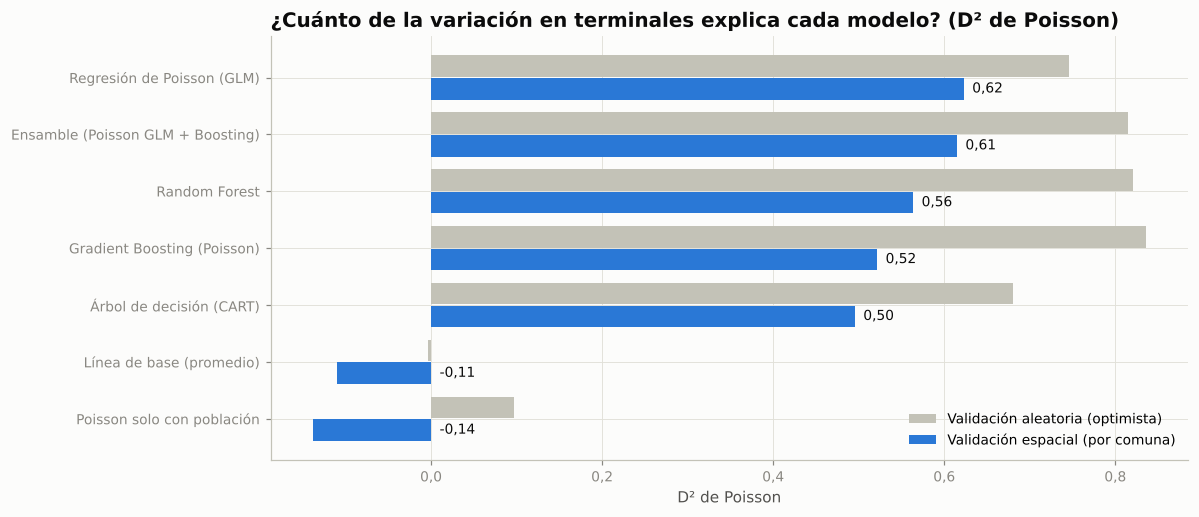

In [4]:
esp = metricas[metricas["validación"].str.startswith("espacial")].set_index("modelo").loc[orden]
ale = metricas[metricas["validación"] == "aleatoria"].set_index("modelo").loc[orden]
fig, ax = plt.subplots(figsize=(11, 4.8))
yy = np.arange(len(orden))
ax.barh(yy - 0.2, ale["D² Poisson"], height=0.38, color=e.EJE, label="Validación aleatoria (optimista)")
ax.barh(yy + 0.2, esp["D² Poisson"], height=0.38, color=e.LINK, label="Validación espacial (por comuna)")
for i, v in enumerate(esp["D² Poisson"]):
    ax.text(max(v, 0) + 0.01, i + 0.2, e.num_es(v, 2), va="center", fontsize=9, color=e.TINTA)
ax.set_yticks(yy, orden); ax.invert_yaxis(); ax.set_xlim(left=min(0, esp["D² Poisson"].min() - 0.05))
ax.set(title="¿Cuánto de la variación en terminales explica cada modelo? (D² de Poisson)", xlabel="D² de Poisson")
ax.legend(loc="lower right"); e.ejes_es(ax, x=1); fig.tight_layout(); fig.savefig(FIG / "modelos_comparacion.png"); plt.show()


**Lectura: por qué elegimos este modelo y no otro.**

- Con la validación **aleatoria** el ranking lo ganan los modelos complejos: Gradient Boosting (Poisson) llega a D² =
  0,84. Con la validación **espacial** el orden se da vuelta: Gradient Boosting (Poisson) cae a
  0,52 y gana la **Regresión de Poisson (GLM)** (D² = 0,62). Los modelos de
  árboles aprenden la geografía de cada zona; cuando les toca una comuna que no vieron, esa memoria no les sirve.
- El **ensamble** definido de antemano (GLM + Boosting) queda en 0,61:
  no mejora al GLM solo, así que por parsimonia nos quedamos con el modelo simple.
- **Solo con población** el modelo es peor que el promedio (D² = -0,14):
  confirma el hallazgo del EDA de que los cajeros no siguen a los vecinos.
- Además del desempeño, el GLM tiene una ventaja de negocio: sus coeficientes se explican en una frase a la gerencia.

El D² espacial de 0,62 significa que el modelo explica cerca de dos tercios de la variación de las
terminales entre zonas que nunca vio, solo con variables de demanda.

## 3. Modelo elegido: qué aprendió

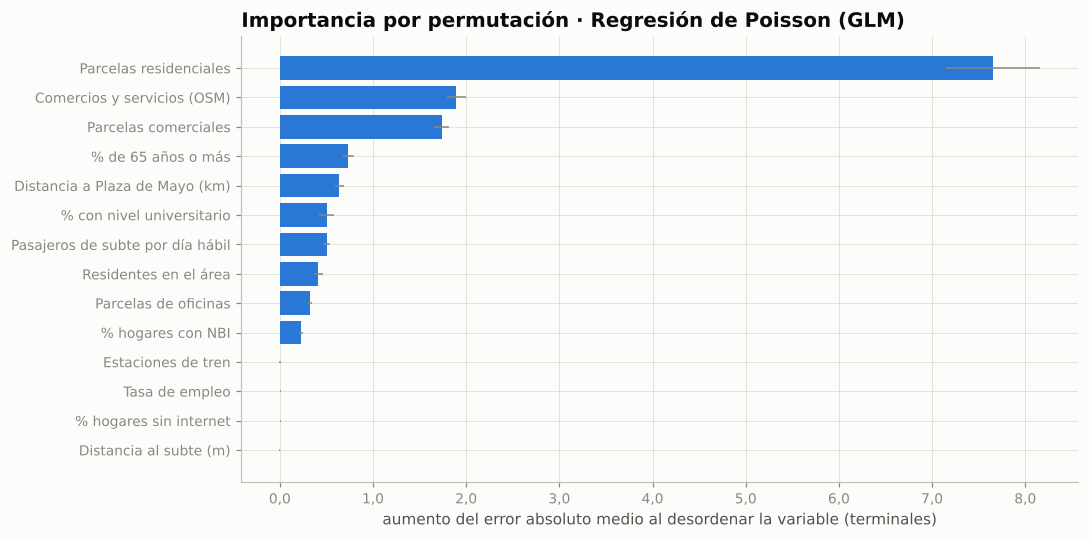

Modelo elegido: Regresión de Poisson (GLM)


In [5]:
ganador = orden.iloc[0]
final = clone(m.candidatos()[ganador]).fit(X, y)
imp = permutation_importance(final, X, y, n_repeats=10, random_state=m.SEMILLA, scoring="neg_mean_absolute_error", n_jobs=-1)
importancia = (pd.DataFrame({"variable": X.columns, "importancia": imp.importances_mean, "desvío": imp.importances_std})
               .assign(nombre=lambda d: d["variable"].map(m.NOMBRES)).sort_values("importancia"))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importancia["nombre"], importancia["importancia"], xerr=importancia["desvío"], color=e.LINK,
        error_kw={"ecolor": e.TINTA_SUAVE, "linewidth": 1})
ax.set(title=f"Importancia por permutación · {ganador}", xlabel="aumento del error absoluto medio al desordenar la variable (terminales)"); e.ejes_es(ax, x=1)
fig.tight_layout(); fig.savefig(FIG / "modelo_importancia.png"); plt.show()
print("Modelo elegido:", ganador)

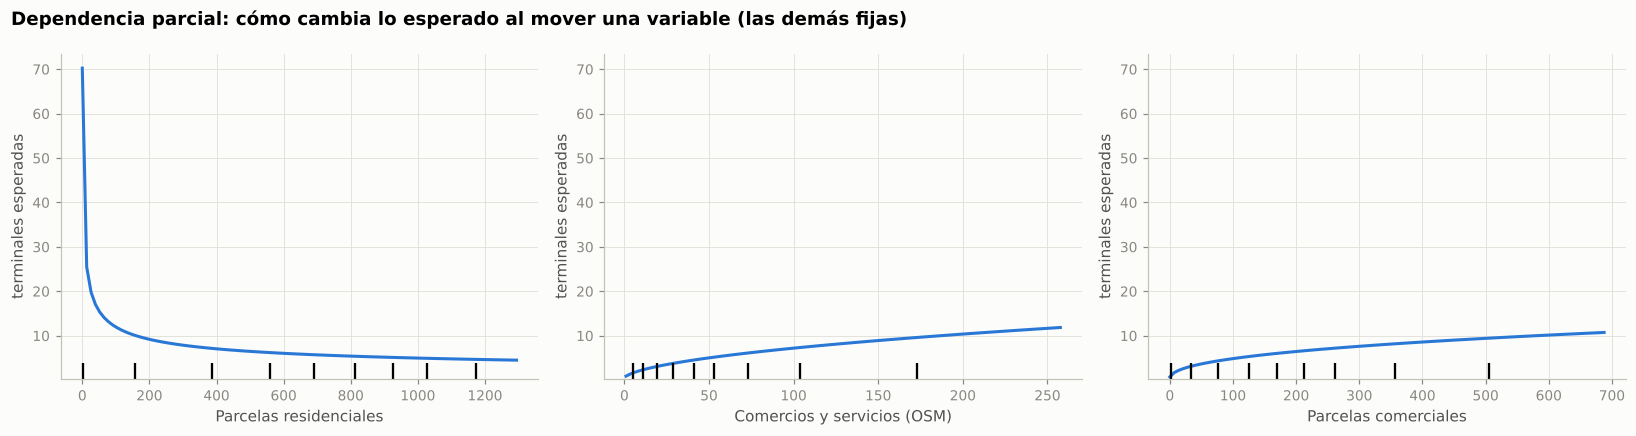

In [6]:
top = importancia.sort_values("importancia", ascending=False)["variable"].head(3).tolist()
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(final, X, top, ax=ax, line_kw={"color": e.LINK, "linewidth": 2})
for a, v in zip(ax, top):
    a.set_xlabel(m.NOMBRES.get(v, v)); a.set_ylabel("terminales esperadas")
fig.suptitle("Dependencia parcial: cómo cambia lo esperado al mover una variable (las demás fijas)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "modelo_dependencia_parcial.png"); plt.show()

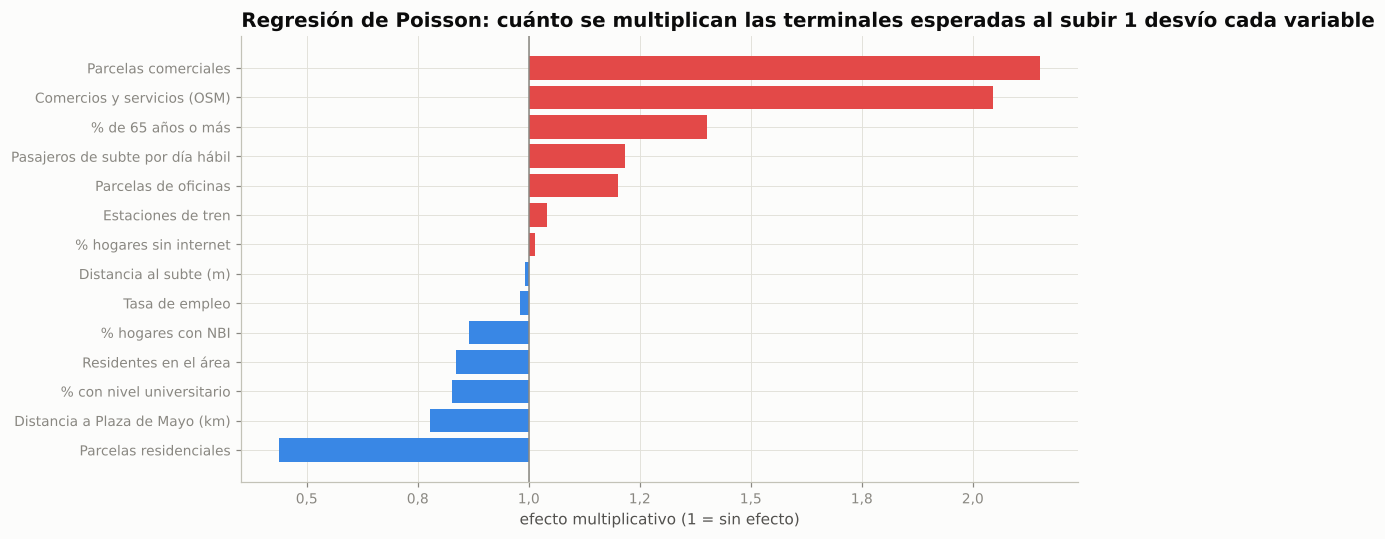

,nombre,coeficiente,efecto
13,Parcelas residenciales,-0.825,0.438
4,Distancia a Plaza de Mayo (km),-0.252,0.777
9,% con nivel universitario,-0.191,0.826
0,Residentes en el área,-0.179,0.836
6,% hogares con NBI,-0.143,0.866
10,Tasa de empleo,-0.019,0.981
5,Distancia al subte (m),-0.009,0.991
7,% hogares sin internet,0.014,1.014
3,Estaciones de tren,0.040,1.041
12,Parcelas de oficinas,0.184,1.201


In [7]:
glm = clone(m.candidatos()["Regresión de Poisson (GLM)"]).fit(X, y)
coef = m.coeficientes_glm(glm, list(X.columns))
fig, ax = plt.subplots(figsize=(10, 5))
colores = [e.DIVERGENTE[-2] if c > 0 else e.DIVERGENTE[1] for c in coef["coeficiente"]]
ax.barh(coef["nombre"], coef["efecto"] - 1, left=1, color=colores)
ax.axvline(1, color=e.TINTA_SUAVE, linewidth=1)
ax.set(title="Regresión de Poisson: cuánto se multiplican las terminales esperadas al subir 1 desvío cada variable",
       xlabel="efecto multiplicativo (1 = sin efecto)")
e.ejes_es(ax, x=1); fig.tight_layout(); fig.savefig(FIG / "modelo_coeficientes.png"); plt.show()
coef[["nombre", "coeficiente", "efecto"]].round(3)


**Lectura.** Con las demás variables fijas, subir un desvío estándar en:
- **parcelas comerciales** multiplica las terminales esperadas por 2,15, y **comercios de OSM** por
  2,05: el comercio es el principal imán de cajeros;
- **% de 65 años o más** las multiplica por 1,40, algo coherente con un uso más intensivo del efectivo en la
  población mayor;
- **pasajeros de subte** por 1,22 y **oficinas** por 1,20;
- **parcelas residenciales** por 0,44: los barrios de casas bajas tienen menos cajeros;
- **% de hogares con NBI** por 0,87: a igual comercio y población, las zonas vulnerables tienen menos oferta.

Ojo al leerlos: algunas variables están correlacionadas entre sí (residentes y parcelas residenciales, por ejemplo), así
que conviene interpretarlas en conjunto. La importancia por permutación coincide en lo principal: tipo de tejido urbano y
comercio primero, transporte y perfil de la población después.

## 4. La brecha

**Brecha total** = terminales esperadas − terminales reales en el área de influencia. Usamos las predicciones **fuera de
muestra** de la validación espacial: cada zona se estima con un modelo que no vio su comuna, así no se "explica" con sus
propios cajeros.

**Brecha Link** = lo que Link tendría con su participación promedio en la ciudad − lo que tiene. Positivo = faltan terminales Link.

Participación de Link en las terminales de la ciudad: 34,5 %


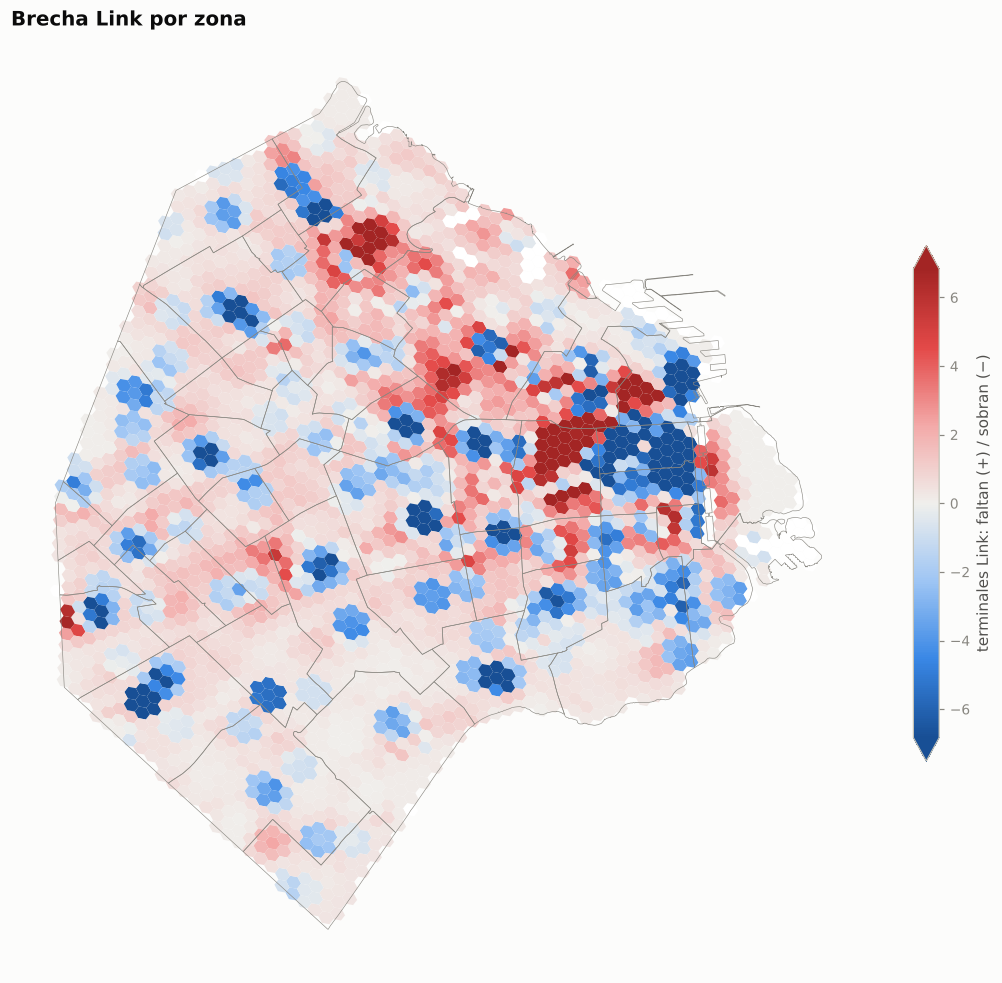

In [8]:
res = m.calcular_brechas(tabla, mascara, oof[ganador])
print(f"Participación de Link en las terminales de la ciudad: {e.num_es(100 * res.attrs['cuota_link'], 1)} %")
g = gpd.GeoDataFrame(res, geometry=[f.poligono_hex(h) for h in res["h3"]], crs="EPSG:4326")
lim = np.nanquantile(np.abs(g["brecha_link"]), 0.95)
fig, ax = plt.subplots(figsize=(10, 9))
g.plot(column="brecha_link", cmap=e.cmap_divergente(), vmin=-lim, vmax=lim, ax=ax, linewidth=0, missing_kwds={"color": "#ffffff"},
       legend=True, legend_kwds={"label": "terminales Link: faltan (+) / sobran (−)", "shrink": 0.55})
barrios.boundary.plot(ax=ax, color=e.TINTA_SUAVE, linewidth=0.4)
ax.set_axis_off(); ax.set_title("Brecha Link por zona")
fig.tight_layout(); fig.savefig(FIG / "mapa_brecha_link.png"); plt.show()

In [9]:
por_barrio = (res.groupby("barrio").agg(residentes=("poblacion", "sum"), link=("term_link", "sum"), banelco=("term_banelco", "sum"),
                                        faltan_link=("brecha_link", lambda s: s.clip(lower=0).sum() / 7))
              .assign(link_10mil=lambda d: d["link"] / d["residentes"] * 1e4)
              .sort_values("faltan_link", ascending=False))
por_barrio.head(12).round(1)

,residentes,link,banelco,faltan_link,link_10mil
barrio,,,,,
Palermo,"242,295.800",47.000,138.000,48.700,1.900
Balvanera,"145,825.000",69.000,78.000,40.800,4.700
Belgrano,"145,111.800",30.000,93.000,31.700,2.100
Recoleta,"160,757.500",57.000,148.000,22.300,3.500
Retiro,"66,256.600",41.000,113.000,12.700,6.200
Villa Crespo,"87,459.600",23.000,30.000,10.700,2.600
Almagro,"146,347.800",22.000,72.000,10.300,1.500
Flores,"152,833.000",26.000,53.000,9.300,1.700
Puerto Madero,"9,520.700",5.000,36.000,8.800,5.300



**Lectura.** La brecha se concentra en los **corredores comerciales del norte y el centro**, donde la demanda predice más
terminales Link de las que hay: **Palermo** (faltan unas 49; Link tiene el 25 % de las terminales, domina Banelco); **Balvanera** (faltan unas 41; Link tiene el 47 % de las terminales, reparto parejo pero mucha demanda); **Belgrano** (faltan unas 32; Link tiene el 24 % de las terminales, domina Banelco). En azul aparece el microcentro, donde Link tiene más de lo que
predice la demanda (allí están las casas centrales de los bancos públicos de la red).

Esta es la oportunidad **competitiva**: zonas con mucha demanda donde Link tiene menos presencia de la que le corresponde.

## 5. Tipos de zona (K-Means)

Agrupamos los hexágonos según su **perfil de demanda** (residentes, comercio y pasajeros en escala logarítmica, distancia al
centro, % NBI, % de 65+ y % universitarios), todo estandarizado. Elegimos k mirando la inercia (método del codo) y la
**silueta** (qué tan separado está cada grupo de los demás).

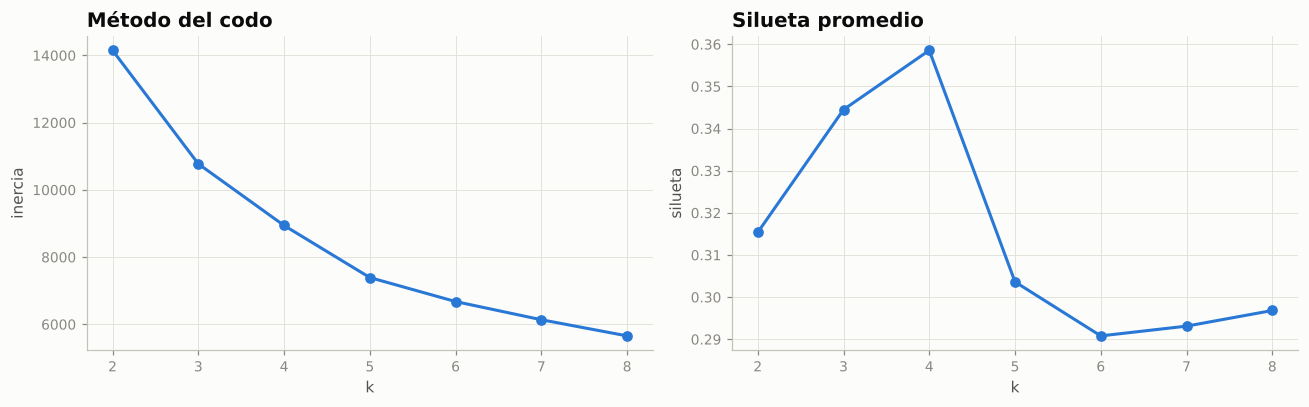

k elegido: 4


,k,inercia,silueta
0,2,"14,150.631",0.315
1,3,"10,773.680",0.344
2,4,"8,939.790",0.359
3,5,"7,390.895",0.304
4,6,"6,676.801",0.291
5,7,"6,135.842",0.293
6,8,"5,655.450",0.297


In [10]:
Z = m.matriz_cluster(res, mascara)
ks = m.elegir_k(Z)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(ks["k"], ks["inercia"], marker="o", color=e.LINK, linewidth=2); ax[0].set(title="Método del codo", xlabel="k", ylabel="inercia")
ax[1].plot(ks["k"], ks["silueta"], marker="o", color=e.LINK, linewidth=2); ax[1].set(title="Silueta promedio", xlabel="k", ylabel="silueta")
fig.tight_layout(); fig.savefig(FIG / "clusters_k.png"); plt.show()
k = int(ks[ks["k"].between(3, 7)].sort_values("silueta", ascending=False).iloc[0]["k"])
print("k elegido:", k)
ks.round(3)

In [11]:
res.loc[mascara, "cluster"] = m.agrupar(Z, k)
nombres = m.nombrar_clusters(res.loc[mascara])
res["tipo_zona"] = res["cluster"].map(nombres)
perfil = (res.loc[mascara].groupby("tipo_zona")
          .agg(hexágonos=("h3", "count"), residentes=("poblacion", "sum"), pasajeros_subte=("pax_subte_habil", "sum"),
               terminales=("term_total", "sum"), terminales_link=("term_link", "sum"),
               dist_centro_km=("dist_centro_km", "median"), pct_nbi=("pct_nbi_k1", "median"), pct_univ=("pct_univ_k1", "median"))
          .assign(terminales_cada_10mil=lambda d: d["terminales"] / d["residentes"] * 1e4,
                  link_cada_10mil=lambda d: d["terminales_link"] / d["residentes"] * 1e4,
                  faltan_link=res.loc[mascara].groupby("tipo_zona")["brecha_link"].apply(lambda s: s.clip(lower=0).sum() / 7))
          .sort_values("residentes", ascending=False))
perfil.round(2)

,hexágonos,residentes,pasajeros_subte,terminales,terminales_link,dist_centro_km,pct_nbi,pct_univ,terminales_cada_10mil,link_cada_10mil,faltan_link
tipo_zona,,,,,,,,,,,
Residencial denso,1563,"1,825,673.240",0.000,967.000,267.000,10.530,0.030,0.190,5.300,1.460,194.770
Corredores comerciales con subte,428,"857,976.230","686,057.600","1,538.000",577.000,4.580,0.040,0.220,17.930,6.730,113.160
Mayor vulnerabilidad social,523,"399,094.450","4,883.700",141.000,70.000,7.490,0.110,0.050,3.530,1.750,19.760
"Zonas sin vecinos (parques, puerto, playones)",226,"4,621.420",0.000,16.000,6.000,8.100,0.040,0.220,34.620,12.980,16.820


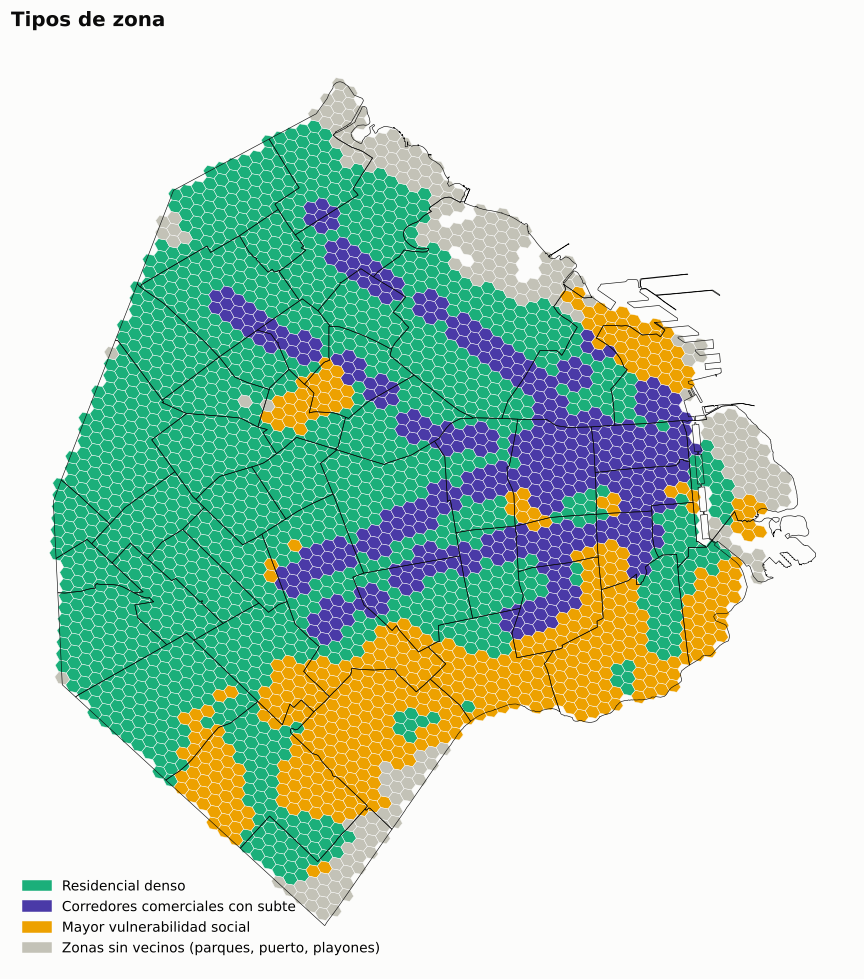

In [12]:
zonas = list(perfil.index)
colores = {z: e.color_zona(z) for z in zonas}
g = gpd.GeoDataFrame(res[res["tipo_zona"].notna()], geometry=[f.poligono_hex(h) for h in res.loc[res["tipo_zona"].notna(), "h3"]], crs="EPSG:4326")
fig, ax = plt.subplots(figsize=(10, 9))
for z in zonas:
    g[g["tipo_zona"] == z].plot(ax=ax, color=colores[z], linewidth=0.3, edgecolor=e.FONDO, label=z)
barrios.boundary.plot(ax=ax, color=e.TINTA, linewidth=0.4)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=colores[z], label=z) for z in zonas], loc="lower left")
ax.set_axis_off(); ax.set_title("Tipos de zona")
fig.tight_layout(); fig.savefig(FIG / "mapa_tipos_zona.png"); plt.show()


**Lectura.** Con k = 4 (silueta = 0,36) aparecen cuatro ciudades distintas:
- **Corredores comerciales con subte:** 857.976 vecinos y casi todo el flujo del subte; 17,9
  terminales cada 10.000 vecinos (6,7 de Link).
- **Residencial denso:** la mayor parte de la ciudad, con 1.825.673 vecinos pero solo
  5,3 terminales cada 10.000 (1,5 de Link).
- **Mayor vulnerabilidad social:** el sur, con NBI mediano de 11 % y 3,5
  terminales cada 10.000 vecinos, la menor oferta por habitante.
- **Zonas sin vecinos:** parques, puerto y playones; quedan como fondo.

Un vecino de un barrio residencial tiene, por habitante, menos de un tercio de las terminales que uno de un corredor comercial.

## 6. Dónde sumar cajeros: cobertura máxima

¿Qué porcentaje de los vecinos tiene un cajero de cada red a menos de 500 m (unas 5 cuadras)? Si está disponible la red
peatonal, la distancia se mide **caminando por las calles** (algoritmo de Dijkstra sobre OpenStreetMap); si no, en línea recta.

In [13]:
cob = m.resumen_cobertura(res, f.RADIO_COBERTURA_M, sufijo=SUF)
if HAY_RED:
    recta = m.resumen_cobertura(res, f.RADIO_COBERTURA_M).set_index("red")["pct_residentes"]
    cob["pct_en_linea_recta"] = cob["red"].map(recta)
    ok = np.isfinite(res["dist_link_m_red"]) & (res["dist_link_m"] > 50)
    print(f"Caminar es, en la mediana, {e.num_es(np.median(res.loc[ok, 'dist_link_m_red'] / res.loc[ok, 'dist_link_m']), 2)} veces la distancia en línea recta")
cob.style.format({"residentes_cubiertos": "{:,.0f}", "pct_residentes": "{:.1%}", "pct_en_linea_recta": "{:.1%}"})

Caminar es, en la mediana, 1,34 veces la distancia en línea recta


,red,residentes_cubiertos,pct_residentes,pct_en_linea_recta
0,Link,"1,580,851",51.2%,68.4%
1,Banelco,"1,990,556",64.4%,79.4%
2,Cualquier red,"2,233,603",72.3%,85.6%


Planteamos el **problema de cobertura máxima** (MCLP, Church y ReVelle, 1974): elegir N ubicaciones que maximicen las
personas que pasan a tener un Link a menos de 500 m. Solo se consideran sitios con comercio o servicios, porque un cajero
necesita un local. Lo resolvemos de dos formas:

- **Algoritmo goloso:** agrega en cada paso el sitio con mayor ganancia marginal. Como la cobertura es submodular, garantiza
  al menos el 63 % (1 − 1/e) del óptimo (Nemhauser, Wolsey y Fisher, 1978). Sirve para la curva de "cuántos cajeros".
- **Óptimo exacto:** el mismo problema como **programa lineal entero**, resuelto con HiGHS (el solver que trae SciPy).

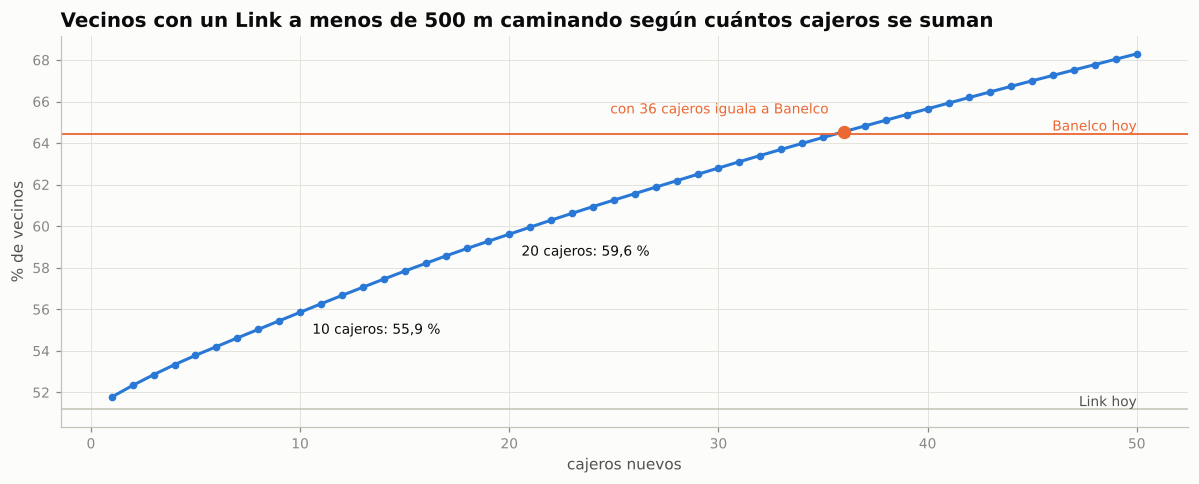

In [14]:
conj = rp.conjuntos_red(res, red, f.RADIO_COBERTURA_M) if HAY_RED else m.conjuntos_recta(res, f.RADIO_COBERTURA_M)
w = m.demanda(res)
recs = m.resolver_goloso(res, 50, conj, w)
recs["tipo_zona"] = recs["h3"].map(res.set_index("h3")["tipo_zona"])
recs["brecha_link"] = recs["h3"].map(res.set_index("h3")["brecha_link"])
total = res["poblacion"].sum()
base = cob.set_index("red").loc["Link", "residentes_cubiertos"]
banelco = cob.set_index("red").loc["Banelco", "pct_residentes"] * 100
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(recs["orden"], (base + recs["personas_acumuladas"]) / total * 100, color=e.LINK, linewidth=2, marker="o", markersize=4)
ax.axhline(base / total * 100, color=e.EJE, linewidth=1)
ax.axhline(banelco, color=e.BANELCO, linewidth=1.2)
ax.text(50, base / total * 100, " Link hoy", va="bottom", ha="right", color=e.TINTA_2, fontsize=9)
ax.text(50, banelco, " Banelco hoy", va="bottom", ha="right", color=e.BANELCO, fontsize=9)
pct = (base + recs["personas_acumuladas"]) / total * 100
for n_ in (10, 20):
    v = pct.iloc[n_ - 1]
    ax.annotate(f"{n_} cajeros: {e.num_es(v, 1)} %", (n_, v), xytext=(8, -14), textcoords="offset points", fontsize=9, color=e.TINTA)
cruce = recs.loc[pct >= banelco, "orden"]
if len(cruce):
    n_c = int(cruce.iloc[0])
    ax.scatter([n_c], [pct.iloc[n_c - 1]], s=60, color=e.BANELCO, zorder=3)
    ax.annotate(f"con {n_c} cajeros iguala a Banelco", (n_c, pct.iloc[n_c - 1]), xytext=(-10, 12), textcoords="offset points",
                ha="right", fontsize=9, color=e.BANELCO)
from matplotlib.ticker import MultipleLocator
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.set(title="Vecinos con un Link a menos de 500 m " + ("caminando " if HAY_RED else "") + "según cuántos cajeros se suman",
       xlabel="cajeros nuevos", ylabel="% de vecinos")
e.ejes_es(ax, y=0)
fig.tight_layout(); fig.savefig(FIG / "cobertura_curva.png"); plt.show()

In [15]:
comp = m.comparar_goloso_exacto(res, conj, w)
comp[["cajeros", "goloso", "exacto", "diferencia_pct", "sitios_en_comun", "seg_exacto"]].round(2)

,cajeros,goloso,exacto,diferencia_pct,sitios_en_comun,seg_exacto
0,5,"80,292.310","80,292.310",0.000,5,0.380
1,10,"144,322.250","144,322.250",-0.000,10,0.460
2,20,"260,452.070","260,452.070",-0.000,20,0.420
3,30,"358,830.620","358,830.620",0.000,30,0.400
4,50,"528,604.040","528,915.920",0.060,43,0.490


In [16]:
exacto = m.resolver_exacto(res, 20, conj, w)
exacto["tipo_zona"] = exacto["h3"].map(res.set_index("h3")["tipo_zona"])
print(f"Óptimo exacto con 20 cajeros: +{e.num_es(exacto.attrs['objetivo'])} vecinos · Link pasa de "
      f"{e.num_es(100 * base / total, 1)} % a {e.num_es(100 * (base + exacto.attrs['objetivo']) / total, 1)} %")
exacto[["orden", "barrio", "comuna", "tipo_zona", "personas_nuevas", "personas_acumuladas"]].round(0)

Óptimo exacto con 20 cajeros: +260.452 vecinos · Link pasa de 51,2 % a 59,6 %


,orden,barrio,comuna,tipo_zona,personas_nuevas,personas_acumuladas
0,1,Belgrano,13,Residencial denso,"18,418.000","18,418.000"
1,2,Balvanera,3,Residencial denso,"17,261.000","35,679.000"
2,3,Villa Lugano,8,Mayor vulnerabilidad social,"15,938.000","51,618.000"
3,4,Barracas,4,Mayor vulnerabilidad social,"14,889.000","66,506.000"
4,5,Barracas,4,Mayor vulnerabilidad social,"13,786.000","80,292.000"
5,6,Palermo,14,Residencial denso,"13,007.000","93,299.000"
6,7,Villa Lugano,8,Mayor vulnerabilidad social,"12,896.000","106,196.000"
7,8,Flores,7,Residencial denso,"12,726.000","118,921.000"
8,9,Almagro,5,Residencial denso,"12,715.000","131,636.000"
9,10,Villa Urquiza,12,Residencial denso,"12,686.000","144,322.000"


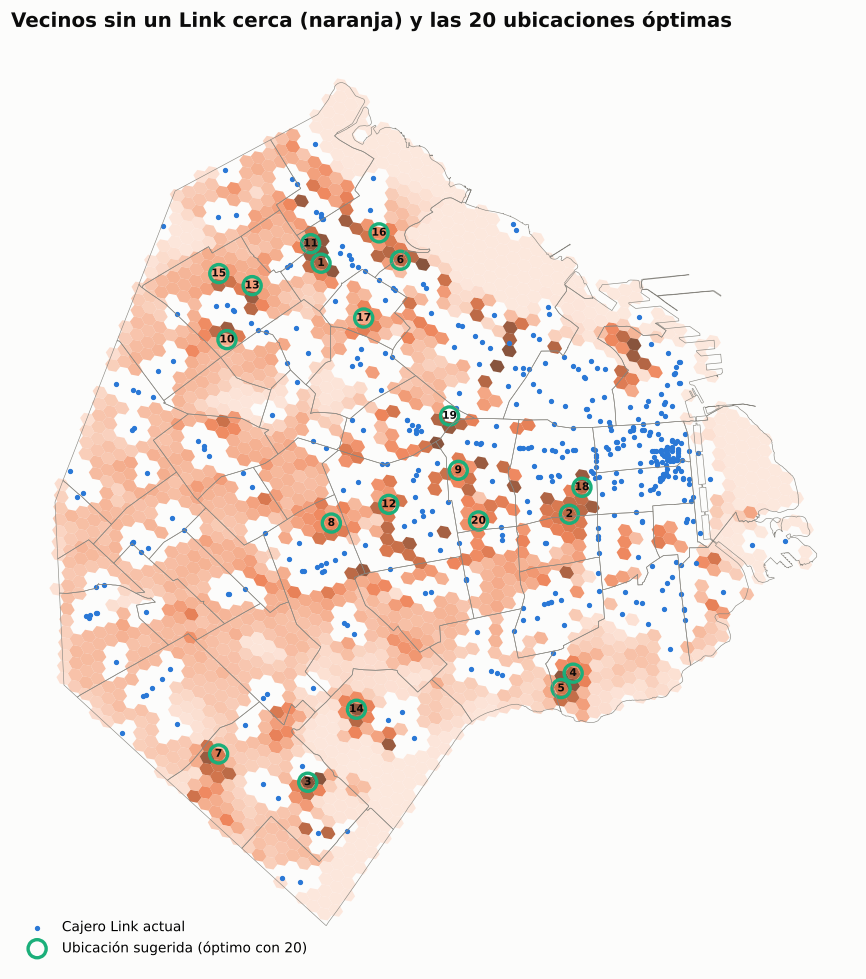

In [17]:
col = "dist_link_m" + SUF
fig, ax = plt.subplots(figsize=(10, 9))
barrios.boundary.plot(ax=ax, color=e.TINTA_SUAVE, linewidth=0.4)
sin = res[res[col] > f.RADIO_COBERTURA_M]
gpd.GeoDataFrame(sin, geometry=[f.poligono_hex(h) for h in sin["h3"]], crs="EPSG:4326").plot(
    ax=ax, column="poblacion", cmap=e.cmap_secuencial(e.SECUENCIAL_NARANJA), linewidth=0, alpha=0.8, vmax=res["poblacion"].quantile(0.98))
lk = cajeros[cajeros["red"] == "LINK"]
ax.scatter(lk["lon"], lk["lat"], s=6, color=e.LINK, label="Cajero Link actual")
ax.scatter(exacto["lon"], exacto["lat"], s=140, facecolor="none", edgecolor=e.SUGERIDO, linewidth=2.2, label="Ubicación sugerida (óptimo con 20)")
for _, r in exacto.iterrows():
    ax.text(r["lon"], r["lat"], str(r["orden"]), fontsize=7, ha="center", va="center", color=e.TINTA, fontweight="bold")
ax.legend(loc="lower left"); ax.set_axis_off()
ax.set_title("Vecinos sin un Link cerca (naranja) y las 20 ubicaciones óptimas")
fig.tight_layout(); fig.savefig(FIG / "mapa_recomendaciones.png"); plt.show()


**Lectura.** Medido caminando por las calles, hoy el **51 %** de los vecinos tiene un Link a menos de 500 m,
contra el **64 %** de Banelco: unas **1.507.883 personas** no tienen
un Link a distancia caminable.

- Con **20 cajeros** en las ubicaciones óptimas, Link suma **260.452 vecinos** y pasa al
  **59,6 %**. La curva muestra rendimientos decrecientes: los primeros 10 cajeros suman
  144.322 vecinos y los siguientes 40, 384.282.
  Con **36 cajeros** bien ubicados, Link igualaría la cobertura que Banelco tiene hoy.
- El **goloso** queda a menos del **0,1 %** del óptimo exacto en todos los casos, y el
  exacto se resuelve en menos de 1 segundo: se puede usar en vivo en la app.
- Las ubicaciones óptimas están en zonas **residenciales densas** (14 de 20; sobre todo
  Belgrano, Villa Urquiza, Almagro) y de **mayor vulnerabilidad social** en el sur (5 de 20;
  Villa Lugano, Barracas, Villa Soldati). Solo 1 cae en un corredor comercial.

Esta es la oportunidad de **cobertura**, distinta de la competitiva: no se trata de competir donde ya hay cajeros sino de
llegar adonde no hay ninguno cerca.

## 7. Validación temporal con datos que el modelo no vio

El listado de cajeros es de ≈2017. OpenStreetMap tiene cajeros mapeados hasta 2026: los que están a más de 150 m de
cualquier cajero del listado son, muy probablemente, **cajeros instalados después**. Si la brecha que calculamos con datos
de 2017 tiene sentido, esos cajeros nuevos deberían aparecer más en zonas con brecha positiva.

Medimos el **AUC**: la probabilidad de que una zona con cajero nuevo tenga más brecha que una zona sin cajero nuevo
(0,5 = azar).

In [18]:
osm = pd.read_csv(RAIZ / "data/base/osm-caba-puntos.csv")
nuevos = m.cajeros_nuevos_osm(osm, cajeros)
modelables = res.loc[mascara]
cerca_de_nuevo = modelables["h3"].isin({v for h in f.hex_de(nuevos["lat"], nuevos["lon"]) for v in f.h3.grid_disk(h, 1)}).astype(int)
validacion = pd.DataFrame([
    {"puntaje": "Brecha total del modelo (datos 2017)", "AUC": m.auc(modelables["brecha_total"].values, cerca_de_nuevo.values)},
    {"puntaje": "Demanda esperada del modelo", "AUC": m.auc(modelables["esperado_total_k1"].values, cerca_de_nuevo.values)},
    {"puntaje": "Solo cantidad de residentes", "AUC": m.auc(modelables["poblacion_k1"].values, cerca_de_nuevo.values)},
])
print(f"Cajeros en OSM 2026: {(osm['categoria'] == 'cajero').sum()} · nuevos (a > 150 m del listado 2017): {len(nuevos)} · "
      f"hexágonos en su área: {cerca_de_nuevo.sum()}")
display(validacion.round(3))
perc = m.percentil_cajeros_nuevos(res, mascara, nuevos)
print(f"Los {perc['n']} cajeros nuevos cayeron, en promedio, en el percentil {e.num_es(100 * perc['percentil_promedio'])} "
      f"de la brecha 2017 · p = {e.num_es(perc['p_valor'], 3)} (Monte Carlo, 20.000 sorteos de zonas al azar)")

Cajeros en OSM 2026: 206 · nuevos (a > 150 m del listado 2017): 9 · hexágonos en su área: 55


,puntaje,AUC
0,Brecha total del modelo (datos 2017),0.651
1,Demanda esperada del modelo,0.610
2,Solo cantidad de residentes,0.509


Los 9 cajeros nuevos cayeron, en promedio, en el percentil 66 de la brecha 2017 · p = 0,049 (Monte Carlo, 20.000 sorteos de zonas al azar)



**Lectura.** De los 206 cajeros mapeados en OpenStreetMap, 9 no tienen
ningún cajero del listado 2017 a menos de 150 m: muy probablemente son **nuevos**. Cayeron en zonas que en 2017 tenían,
en promedio, más brecha que el 66 % de la ciudad (p = 0,049
frente a zonas elegidas al azar). El AUC de la brecha es 0,65, contra 0,51 de mirar solo la población.

Es una **evidencia a favor, pero modesta**: son pocos cajeros y OpenStreetMap no está completo. La leemos así: el mercado
tendió a instalar cajeros donde el modelo marcaba faltante, y no al azar.

## 8. Conclusión


**Respuesta a la hipótesis.** Sí: en CABA hay zonas con demanda y pocos cajeros Link, y se pueden detectar y priorizar con
datos públicos. Aparecen **dos oportunidades distintas**:

1. **Competir** en los corredores comerciales del norte y el centro (Palermo, Balvanera, Belgrano), donde la
   demanda justifica más terminales Link de las que hay.
2. **Cubrir** los barrios residenciales (Belgrano, Villa Urquiza, Almagro) y el sur (Villa Lugano, Barracas, Villa Soldati), donde
   1.507.883 vecinos no tienen un
   Link a distancia caminable. Con 20 cajeros bien ubicados, Link pasa del 51 % al
   59,6 % de cobertura y la diferencia con Banelco baja de
   13 a 5 puntos.

**Cómo usarlo:** la gerencia elige la estrategia (competir o cubrir), el simulador de la app devuelve las ubicaciones y su
impacto, y con el listado actual de cajeros se recalcula todo en segundos.

**Limitaciones:** la oferta es de ≈2017; la demanda se estima sin transacciones reales; la brecha compara contra el
promedio del mercado (si todo el mercado desatiende una zona, la brecha no lo ve; por eso la optimización mide cobertura y
no brecha).